In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [7]:
from sklearn.metrics import accuracy_score

dimensions de X: (100, 2)
dimensions de y: (100, 1)


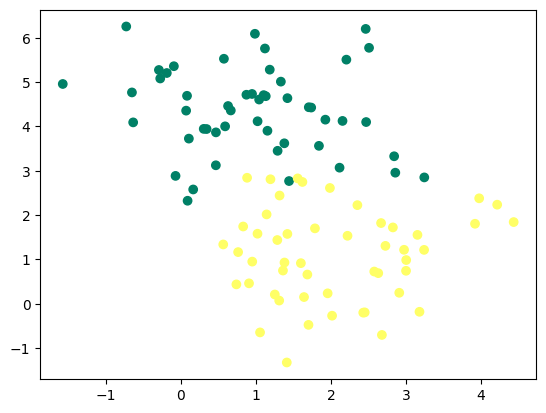

In [8]:
X, y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
y = y.reshape((y.shape[0], 1))

print('dimensions de X:', X.shape)
print('dimensions de y:', y.shape)

plt.scatter(X[:,0], X[:, 1], c=y, cmap='summer')
plt.show()

In [9]:
def initialisation(X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn(1)
    return (W, b)

In [10]:
def model(X, W, b):
    Z = X.dot(W) + b
    # print(Z.min())
    A = 1 / (1 + np.exp(-Z))
    return A

In [11]:
def logloss(A, y):
    #Bonne pratique pour eviter de calculer des log en 0
    epsilon = 1e-15
    return 1 / len(y) * np.sum(-y * np.log(A+epsilon) - (1 - y) * np.log(1 - A+epsilon))

In [12]:
def gradients(A,X,y):
    dW = 1 / len(y) * np.dot(X.T, A - y)
    db = 1 / len(y) * np.sum(A - y)
    return (dW, db)

In [13]:
def update_gradient(dW, db , W , b , lr):
    W = W - lr * dW
    b = b - lr * db
    return (W, b) 

In [14]:
def predict(X,W,b):
    A = model(X, W, b)
    print(A)
    return A>0.5

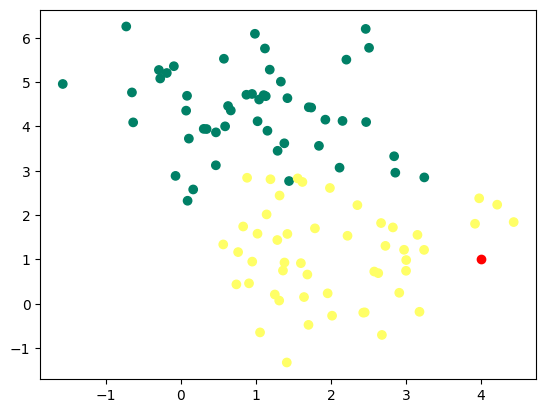

In [18]:
new_plant = np.array([4,1])
plt.scatter(X[:,0], X[:, 1], c=y, cmap='summer')
plt.scatter(new_plant[0], new_plant[1], c='r')
plt.show()


In [19]:
def compute(X,y,lr = 0.1,n_iter = 100):
    W,b = initialisation(X)
    loss = []
    for i in range(n_iter): 
        A = model(X ,W,b)
        loss.append(logloss(A,y))
        dW,db = gradients(A,X,y)
        W,b = update_gradient(dW,db , W,b ,lr)

    y_pred = predict(X,W,b)
    print(accuracy_score(y,y_pred))
    
    plt.plot(loss)
    plt.show() 

    return (W,b)


[[0.96153278]
 [0.69657559]
 [0.00818003]
 [0.13572774]
 [0.95105252]
 [0.34977402]
 [0.08684343]
 [0.94254787]
 [0.05888847]
 [0.81387074]
 [0.04146941]
 [0.83075559]
 [0.03865338]
 [0.02362886]
 [0.68282962]
 [0.97896947]
 [0.98465633]
 [0.04462256]
 [0.65681853]
 [0.59858388]
 [0.06097026]
 [0.04717743]
 [0.38329282]
 [0.00813021]
 [0.93134342]
 [0.04411636]
 [0.84165177]
 [0.01495357]
 [0.08746234]
 [0.72609794]
 [0.96349014]
 [0.0588267 ]
 [0.6077789 ]
 [0.96411449]
 [0.40466817]
 [0.27078525]
 [0.72631037]
 [0.54504519]
 [0.48002797]
 [0.40585173]
 [0.07210001]
 [0.11292376]
 [0.00163988]
 [0.18694578]
 [0.20370846]
 [0.80907497]
 [0.94444281]
 [0.93344824]
 [0.00690977]
 [0.01513251]
 [0.90915031]
 [0.50377351]
 [0.07568493]
 [0.057896  ]
 [0.81533146]
 [0.05786838]
 [0.71527648]
 [0.77787792]
 [0.93354365]
 [0.982539  ]
 [0.60752311]
 [0.21536828]
 [0.00792699]
 [0.90564269]
 [0.02354111]
 [0.36936793]
 [0.04293199]
 [0.6377853 ]
 [0.92775675]
 [0.29741427]
 [0.19402806]
 [0.88

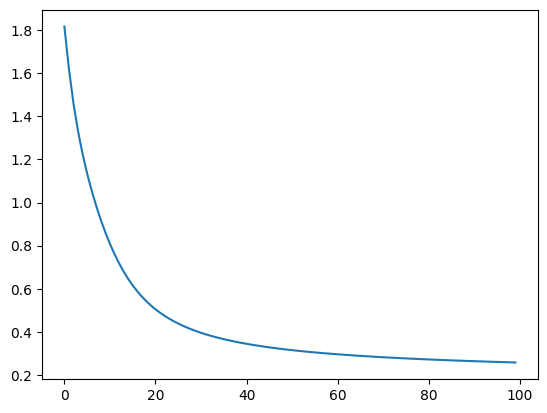

In [21]:
w,b = compute(X,y)